ES I : CMB PARAMETER SENSITIVITY

1)The standard cosmological model, lambdaCDM, is defined by the values of six parameters: (As; ns; tau;H0;omega bh2;omega ch2). Explore the CAMB example notebook and familiarize yourself with the different quantities that the code computes and can plot. Run CAMB for reference values of these parameters (either CAMB default of Planck 2018 best-fit results). Plot the CMB temperature power spectrum.  
 2)Plot the monopole, dipole, early/late ISW contributions to the spectrum (check the extra example notebook that is provided with CAMB).  
 3)Vary these parameters by 10% of their value. Plot both the full temperature spectrum and different contributions (monopole, dipole, early/late ISW). How and why do they change? Describe these changes and why they are happening.
You can find it useful to use the markdown feature of jupiter notebooks that allows you to mix text and code and take a note of your results (i.e. write down your considerations, you do not need to memorize them for the exam).

1) THEORETICAL BACKGROUND: The LambdaCDM model (CDM= Cold Dark Matter) is the current standard model of cosmology. It describes the evolution and structure of the universe using a minimal set of six parameters, including the densities of baryons and dark matter, the Hubble constant, the amplitude and tilt of primordial fluctuations, and the optical depth due to reionization.
One of the most powerful observational tools to constrain these parameters is the CMB (Cosmic Microwave Background ),which is the relic radiation from the early universe. The CMB is uniform, but it contains tiny temperature anisotropies at the level of $10^{-5}$, which encode detailed information about the physical conditions of the early universe.These anisotropies are statistically described by the CMB temperature power spectrum, which quantifies the variance of temperature fluctuations as a function of angular scale.

H0 (Hubble parameter): 67.66 km/s/Mpc
omega_b h^2 (baryon density): 0.02242
omega_c h^2 (cold dark matter density): 0.11934
tau (optical depth): 0.0544
As (scalar amplitude): 2.100e-09
n_s (scalar spectral index): 0.9649


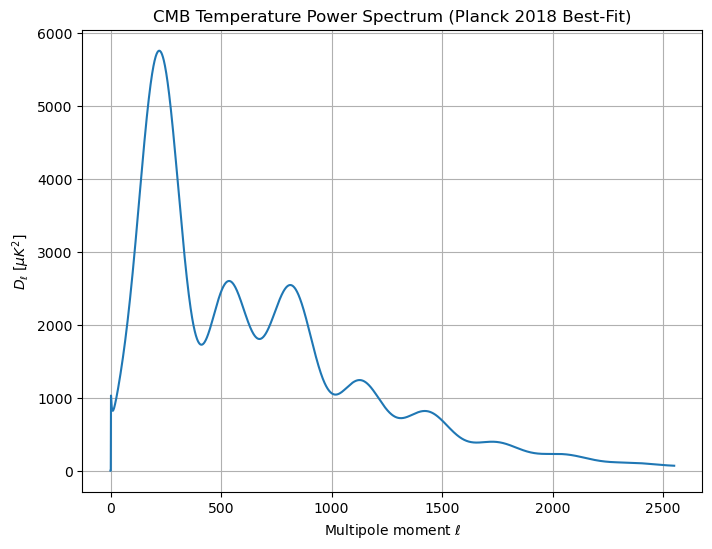

In [1]:
import camb
from camb import model, initialpower
import matplotlib.pyplot as plt
from astropy.cosmology import Planck18

# Importo parametri Planck 2018 direttamente da astropy
H0 = Planck18.H0.value
ombh2 = Planck18.Ob0 * Planck18.h**2
omch2 = Planck18.Odm0 * Planck18.h**2
tau = 0.0544  # optical depth, Planck 2018 best-fit
As = 2.100e-9  # scalar amplitude, Planck 2018 best-fit
ns = 0.9649    # scalar spectral index, Planck 2018 best-fit

# Stampo i parametri
print(f"H0 (Hubble parameter): {H0:.2f} km/s/Mpc")
print(f"omega_b h^2 (baryon density): {ombh2:.5f}")
print(f"omega_c h^2 (cold dark matter density): {omch2:.5f}")
print(f"tau (optical depth): {tau}")
print(f"As (scalar amplitude): {As:.3e}")
print(f"n_s (scalar spectral index): {ns}")

# Configuro CAMB con questi parametri
pars = camb.CAMBparams()
pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2, tau=tau)
pars.InitPower.set_params(As=As, ns=ns)
pars.set_for_lmax(2500, lens_potential_accuracy=0)  #multipolo max a l=2500
#si ignora il lensing, per calcolo piu veloce

# Calcolo lo spettro
results = camb.get_results(pars)  #camb esegue tutti i calcoli numerici e produce gli spettri, che metto sotto nel dizionario powers
powers = results.get_cmb_power_spectra(pars, CMB_unit='muK')

# Plot dello spettro TT=spettro più noto, delle fluttuazioni di temperatura
totCL = powers['total']
plt.figure(figsize=(8,6))
plt.plot(totCL[:,0])
plt.xlabel(r'Multipole moment $\ell$')
plt.ylabel(r'$D_\ell$ [$\mu K^2$]')
plt.title('CMB Temperature Power Spectrum (Planck 2018 Best-Fit)')
plt.grid()
plt.show()


MARKDOWN:  
questo è il grafico delle anisotropie della radiazione microonde cosmica di fondo (CMB), con sull'asse delle x il momento multipolare l (piccoli l corrispondo a scale angolari grandi e viceversa) e sull'asse delle y c'è Dl, derivato da Cl che è la varianza delle anisotropie, e che coincide con:  
        $D_l=\frac{l(l+1)\cdot C_l}{2\pi}$  
Il grafico descrive le fluttuazioni di temperatura della CMB proiettate nel cielo,al tempo della ricombinazione.
Si osserva che:
1) a sinistra c'è una regione con modi che sono congelati, non oscillano, in quanto non sono ancora entrati nell'orizzonte all'epoca di ricombinazione  (NB: si ricorda che perturbazioni con lunghezza d'onda più piccola entrano prima della ricombinazione, mentre se $\lambda$ più grossa e quindi l più piccola, entrano dopo ricombinazione)  
2) dopo essere entrati nell'orizzonte si presenta un andamento oscillante, con 3 picchi principali: il primo picco (l=220) rappresenta la scala angolare dell'orizzonte sonoro alla ricombinazione ed inoltre è il picco di compressione acustica del plasma fotone-barioni, il secondo picco invece rappresenta il momento di rarefazione e il terzo picco la seconda compressione   
 3) le oscillazione a scale di l grossi calano rapidamente a causa di effetti di damping (silk= scala è più piccola del libero cammino medio dei fotoni, quindi la diffusione random di fotoni può eliminare il contrasto di densità nel plasma e quindi diminuire l'ampiezza delle oscillazioni)

2) THEORETICAL BACKGROUND: While the total CMB temperature power spectrum provides a global picture of how temperature fluctuations vary across angular scales, it is composed of several physically distinct contributions that arise from different processes in the early and late universe.  
MONOPOLE(SACHS-WOLFE EFFECT): corresponds to the gravitational redshift of photons at the surface of last scattering. It is the dominant contribution at large angular scales. It reflects the potential wells photons had to climb out of when decoupling from matter.  
DIPOLE(DOPPLER EFFECT): comes from the peculiar velocity of the baryon-photon fluid at recombination. It's most significant around the first acoustic peak and its harmonics.  
ISW (INTEGRATED SACHS_WOLFE) EFFECT, EARLY:  is produced during the radiation-to-matter transition era, when gravitational potentials evolve slightly, so the photons have to exit the wells (formed by grav.pot.) using  more/less energy than they used once they have entered.This affects the temperature fluctuations at intermediate angular scales. 
ISW (INTEGRATED SACHS_WOLFE) EFFECT, LATE: arises in the dark-energy-dominated era, when gravitational potentials decay due to the accelerated expansion of the universe. This contribution boosts the power at very large angular scales(l=30). 

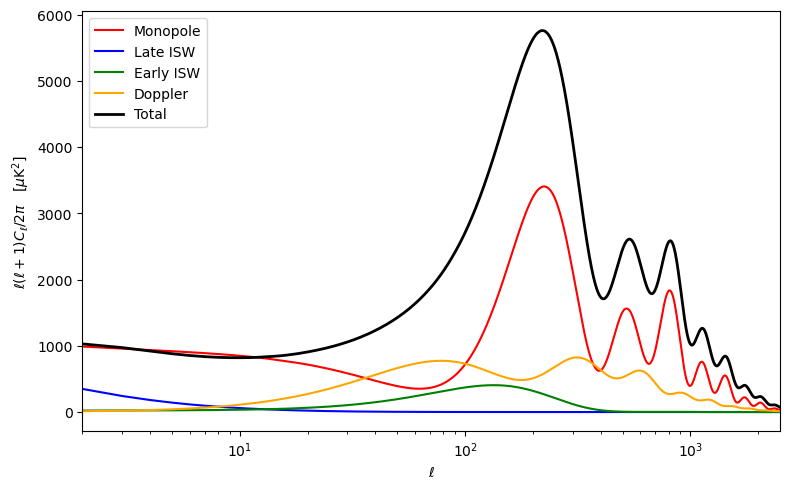

In [2]:
import camb
import matplotlib.pyplot as plt
import numpy as np
import sympy
from camb.symbolic import get_scalar_temperature_sources

# Setup cosmologia (planck-18)
pars = camb.set_params(H0=67.66, ombh2=0.02242, omch2=0.11934, As=2.1e-9, ns=0.9649, tau=0.0544)
#(H0=67.5, ombh2=0.022, omch2=0.122, As=2e-9, ns=0.95, tau=0.055) 

# Ottengo le sorgenti di temperatura simboliche
monopole_source, ISW, doppler, quadrupole_source = get_scalar_temperature_sources()

# Definisco separazione tra early e late ISW: early è quando z>30, late al contrario
a = sympy.Symbol('a')
early_ISW = sympy.Piecewise((ISW, 1 / a - 1 > 30), (0, True))  # z > 30
late_ISW = ISW - early_ISW

# Registro le sorgenti personalizzate
names = ['mon', 'ISW', 'eISW', 'LISW', 'dop', 'Q']
pars.set_custom_scalar_sources(
    [monopole_source, ISW, early_ISW, late_ISW, doppler, quadrupole_source],
    source_names=names)

# Calcolo spettro
data = camb.get_results(pars)
dic = data.get_cmb_unlensed_scalar_array_dict(CMB_unit='muK')  #estrae spettri e converte Cl in unità fisiche
#dentro a questo dizionario trovo: monxmon, LISWxLISW,eISWxEISW,dopxdop,TxT   (autocorrelazioni perchè sto facendo Cl=<a_lm a_l'm'*>)


# Preparo multipoli
ls = np.arange(dic['TxT'].shape[0])  #creo array di interi, l
cl_label = r'$\ell(\ell+1)C_\ell/2\pi\quad [\mu {\rm K}^2]$'

# Plot dei contributi
plt.figure(figsize=(8, 5))
plt.semilogx(ls, dic['monxmon'], color='red', label='Monopole')
plt.semilogx(ls, dic['LISWxLISW'], color='blue', label='Late ISW')
plt.semilogx(ls, dic['eISWxeISW'], color='green', label='Early ISW')
plt.semilogx(ls, dic['dopxdop'], color='orange', label='Doppler') 
plt.semilogx(ls, dic['TxT'], lw=2, color='k', label='Total')
plt.xlabel(r'$\ell$')
plt.ylabel(cl_label)
plt.xlim(2, ls[-1])
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


MARKDOWN:
1) shows the acoustic peaks given by harmonic oscillations,they are not centered in 0 (baryon loading), the amplitude grows at the beginning (radiation driving) and then it decreases at large multipoles (l) because of the dampings (Silk and Landau)
2) monopole and dipole are out of phase (max monopole is min dipole and viceversa) and because of that in the total the troughs become less pronounced  
3) adding the  Integrated Sachs–Wolfe effect enhances the anisotropy mostly on scales comparable to or larger than the horizon at recombination, thus the first peak gets most of the additional power  

3) 

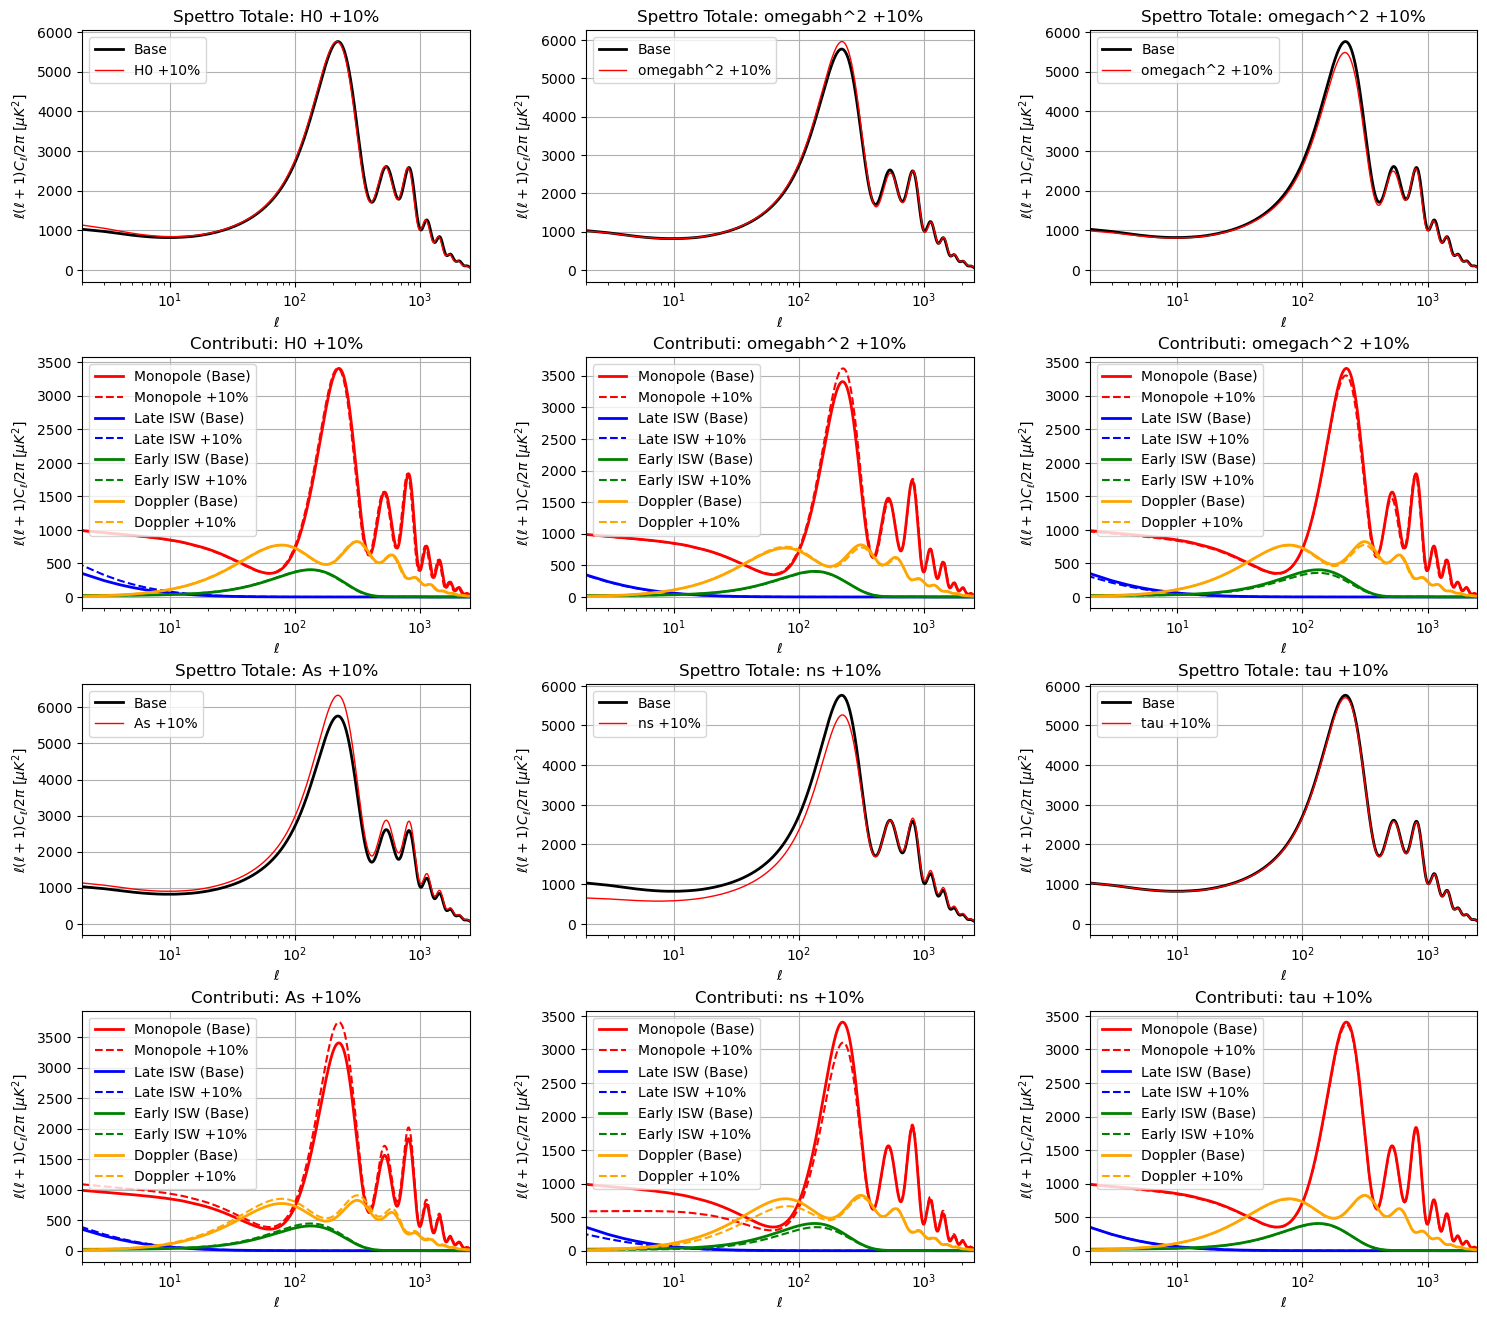

In [3]:
# Parametri base
params_base = {
    'H0': 67.66,
    'ombh2': 0.02242,
    'omch2': 0.11934,
    'As': 2.1e-9,
    'ns': 0.9649,
    'tau': 0.0544}

param_names = {  #etichette per i parametri
    'H0': 'H0',
    'ombh2': 'omegabh^2',
    'omch2': 'omegach^2',
    'As': 'As',
    'ns': 'ns',
    'tau': 'tau'}

# Funzione per calcolare spettro e contributi
def get_spectra(pars_dict):
    pars = camb.set_params(**pars_dict)
    monopole_source, ISW, doppler, quadrupole_source = get_scalar_temperature_sources()
    a = sympy.Symbol('a')
    early_ISW = sympy.Piecewise((ISW, 1 / a - 1 > 30), (0, True))
    late_ISW = ISW - early_ISW
    names = ['mon', 'ISW', 'eISW', 'LISW', 'dop', 'Q']
    pars.set_custom_scalar_sources(
        [monopole_source, ISW, early_ISW, late_ISW, doppler, quadrupole_source],
        source_names=names
    )
    data = camb.get_results(pars)
    dic = data.get_cmb_unlensed_scalar_array_dict(CMB_unit='muK')
    return dic

# Calcolo spettro base (linea continua)
dic_base = get_spectra(params_base)
ls = np.arange(dic_base['TxT'].shape[0])

# Parametri da variare
param_list = ['H0', 'ombh2', 'omch2', 'As', 'ns', 'tau']

# Preparo figure
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
plt.subplots_adjust(hspace=0.3, wspace=0.3)

for i, param in enumerate(param_list):
    row_total = 0 if i < 3 else 2   #fa griglia di plot
    row_contrib = 1 if i < 3 else 3
    col = i % 3

    # Variazione +10%
    params_var = params_base.copy()
    params_var[param] *= 1.1  #variazione del 10%
    dic_var = get_spectra(params_var)  #spettro variato

    # Plotto
    ax = axes[row_total, col]
    ax.semilogx(ls, dic_base['TxT'], color='k', lw=2, label='Base')
    ax.semilogx(ls, dic_var['TxT'], color='r', lw=1, label=f'{param_names[param]} +10%')
    ax.set_xlabel(r'$\ell$')
    ax.set_ylabel(r'$\ell(\ell+1)C_\ell/2\pi\ [\mu K^2]$')
    ax.set_title(f'Spettro Totale: {param_names[param]} +10%')
    ax.set_xlim(2, ls[-1])
    ax.grid()
    ax.legend()

    # --- Contributi ---
    axc = axes[row_contrib, col]
    axc.semilogx(ls, dic_base['monxmon'], color='red', lw=2, label='Monopole (Base)')
    axc.semilogx(ls, dic_var['monxmon'], ls='--', color='red', label='Monopole +10%')

    axc.semilogx(ls, dic_base['LISWxLISW'], color='blue', lw=2, label='Late ISW (Base)')
    axc.semilogx(ls, dic_var['LISWxLISW'], ls='--', color='blue', label='Late ISW +10%')

    axc.semilogx(ls, dic_base['eISWxeISW'], color='green', lw=2, label='Early ISW (Base)')
    axc.semilogx(ls, dic_var['eISWxeISW'], ls='--', color='green', label='Early ISW +10%')

    axc.semilogx(ls, dic_base['dopxdop'], color='orange', lw=2, label='Doppler (Base)')
    axc.semilogx(ls, dic_var['dopxdop'], ls='--', color='orange', label='Doppler +10%')


    axc.set_xlabel(r'$\ell$')
    axc.set_ylabel(r'$\ell(\ell+1)C_\ell/2\pi\ [\mu K^2]$')
    axc.set_title(f'Contributi: {param_names[param]} +10%')
    axc.set_xlim(2, ls[-1])
    axc.grid()
    axc.legend()

plt.show()


MARKDOWN : (si è utilizzato il libro Dodelson, capitolo 9)
1) se aumento H0->universo si sta espandendo più velocemente oggi->età universo (integrale di 1/aH(a)) più bassa-> riduco la distanza comovente dal LSS ($\chi_*$), per questo si ottiene che le oscillazioni subiscono uno shift e late iSW aumenta (poiché anticipo la dominanza dell'energia oscura, quindi i potenziali decadono prima, in modo più rapido quindi integrale della derivata del potenziale è più grande)
2)  più barioni-> più massa -> più importante il baryon loading (picchi dispari aumentano, quelli in compressione)  
3) più materia oscura -> pozzi di gravità più profondi e soprattutto più stabili -> meno spinta extra sulle oscillazioni -> oscillazioni (in particolare primo picco) meno amplificate; inoltre epoca uguaglianza mat-rad avviene prima -> universo entra prima nell'epoca materia -> potenziali smettono di decadere -> early ISW è più debole (a bassi l)  
4) As è un fattore moltiplicativo, fa restare la stessa forma ma tutti i contributi aumentano sulle y se aumentato 
5) se aumento ns -> Cl cambia a grandi l con un fattore $(l/lp)^{\alpha}$, mentre a piccoli l questo approccio non vale  
6) se aumento tau (optical depth da reionizz) -> ho re-ionizzato prima l'universo -> più fotoni CMB sono stati diffusi una seconda volta da elettroni liberi prodotti da stelle e galassie -> Cl un poco attenuato a grandi l


NOW WE PUT IT ALL-TOGETHER

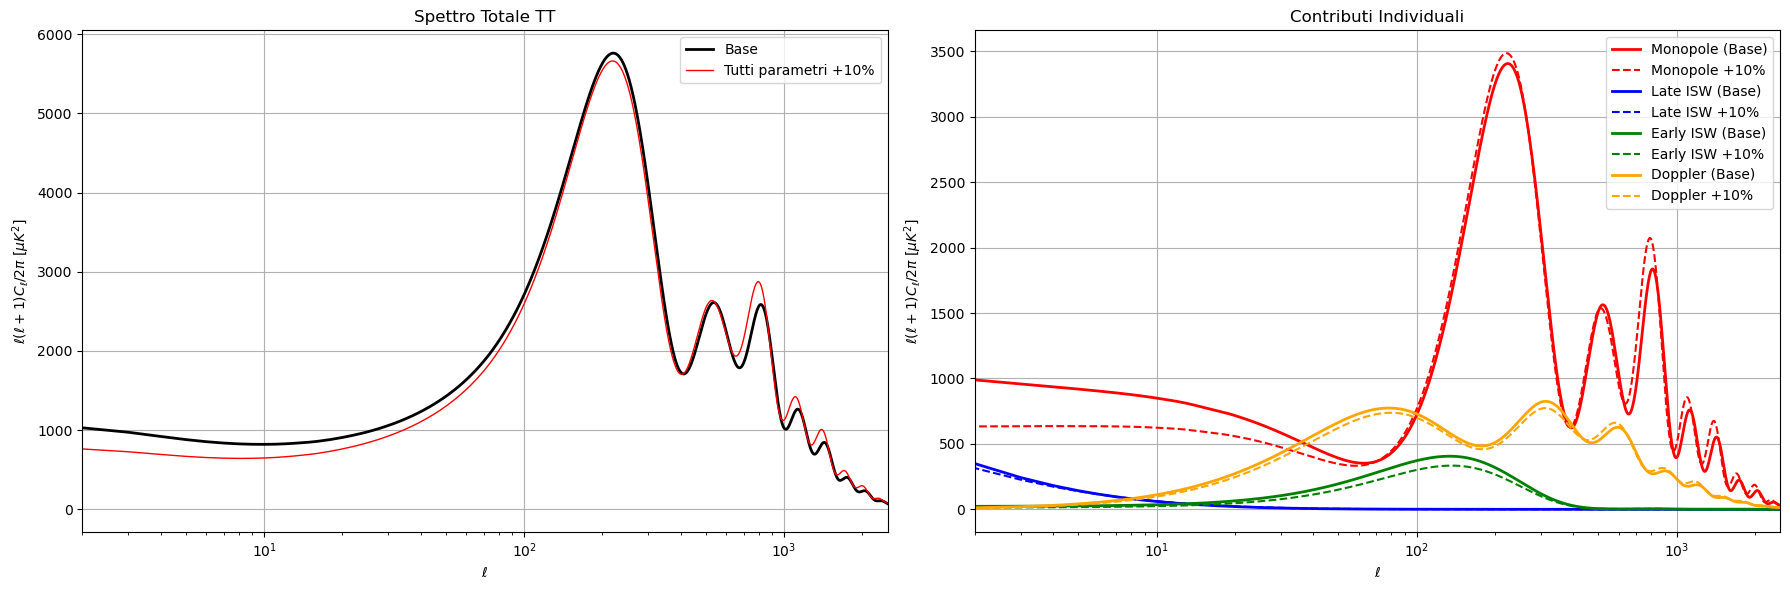

In [4]:
# Calcolo spettro base e +10%
dic_base = get_spectra(params_base)
params_all_up = {k: v * 1.1 for k, v in params_base.items()}
dic_up = get_spectra(params_all_up)
ls = np.arange(dic_base['TxT'].shape[0])

# Preparo figure 
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plotto
ax1 = axes[0]
ax1.semilogx(ls, dic_base['TxT'], color='k', lw=2, label='Base')
ax1.semilogx(ls, dic_up['TxT'], color='r', lw=1, label='Tutti parametri +10%')
ax1.set_xlabel(r'$\ell$')
ax1.set_ylabel(r'$\ell(\ell+1)C_\ell/2\pi\ [\mu K^2]$')
ax1.set_title('Spettro Totale TT')
ax1.set_xlim(2, ls[-1])
ax1.legend()
ax1.grid()

ax2 = axes[1]
ax2.semilogx(ls, dic_base['monxmon'], color='red', lw=2, label='Monopole (Base)')
ax2.semilogx(ls, dic_up['monxmon'], ls='--', color='red', label='Monopole +10%')

ax2.semilogx(ls, dic_base['LISWxLISW'], color='blue', lw=2, label='Late ISW (Base)')
ax2.semilogx(ls, dic_up['LISWxLISW'], ls='--', color='blue', label='Late ISW +10%')

ax2.semilogx(ls, dic_base['eISWxeISW'], color='green', lw=2, label='Early ISW (Base)')
ax2.semilogx(ls, dic_up['eISWxeISW'], ls='--', color='green', label='Early ISW +10%')

ax2.semilogx(ls, dic_base['dopxdop'], color='orange', lw=2, label='Doppler (Base)')
ax2.semilogx(ls, dic_up['dopxdop'], ls='--', color='orange', label='Doppler +10%')

ax2.set_xlabel(r'$\ell$')
ax2.set_ylabel(r'$\ell(\ell+1)C_\ell/2\pi\ [\mu K^2]$')
ax2.set_title('Contributi Individuali')
ax2.set_xlim(2, ls[-1])
ax2.legend()
ax2.grid()
plt.tight_layout()
plt.show()


REDONE WITH -10%

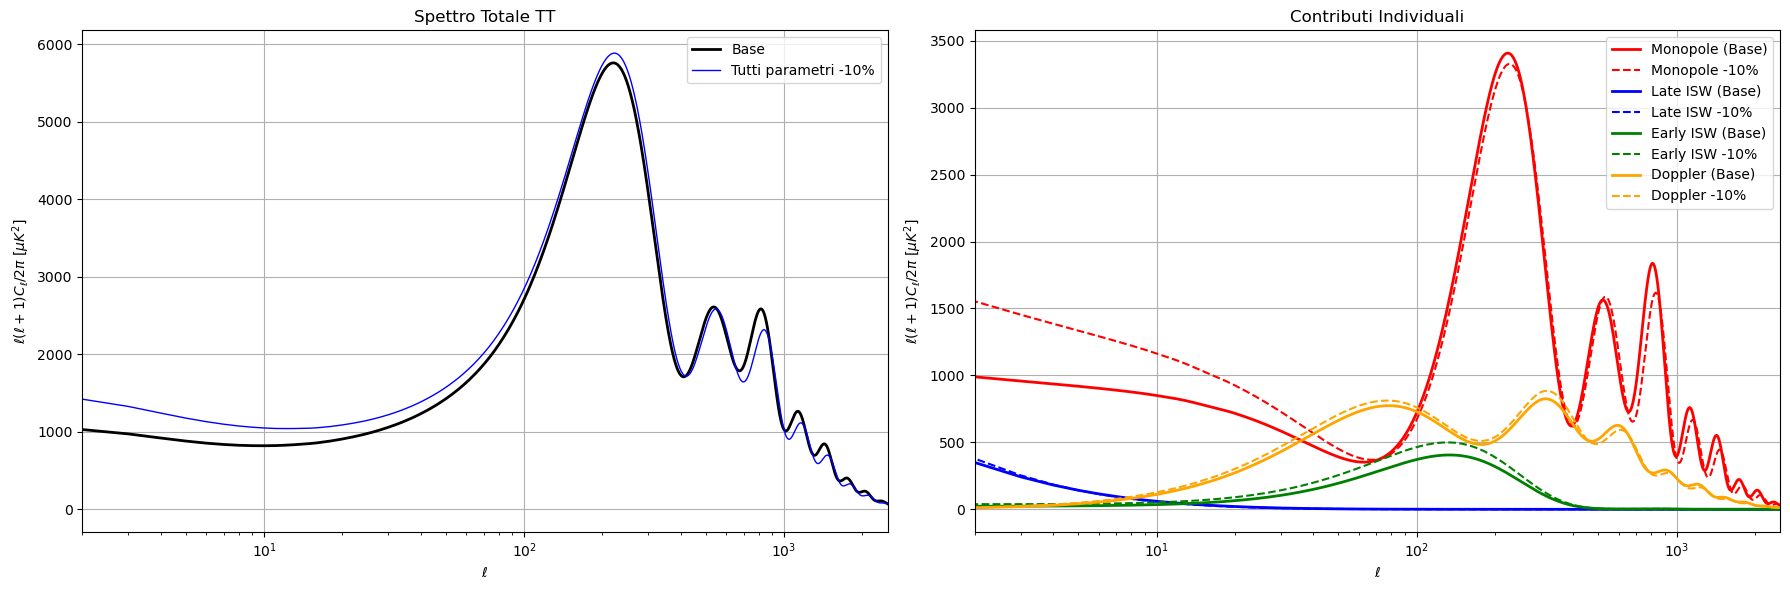

In [5]:
# Costruisco parametri con tutti -10%
params_all_down = {k: v * 0.9 for k, v in params_base.items()}
dic_down = get_spectra(params_all_down)


fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax1 = axes[0]
ax1.semilogx(ls, dic_base['TxT'], color='k', lw=2, label='Base')
ax1.semilogx(ls, dic_down['TxT'], color='b', lw=1, label='Tutti parametri -10%')
ax1.set_xlabel(r'$\ell$')
ax1.set_ylabel(r'$\ell(\ell+1)C_\ell/2\pi\ [\mu K^2]$')
ax1.set_title('Spettro Totale TT')
ax1.set_xlim(2, ls[-1])
ax1.legend()
ax1.grid()

ax2 = axes[1]
ax2.semilogx(ls, dic_base['monxmon'], color='red', lw=2, label='Monopole (Base)')
ax2.semilogx(ls, dic_down['monxmon'], ls='--', color='red', label='Monopole -10%')

ax2.semilogx(ls, dic_base['LISWxLISW'], color='blue', lw=2, label='Late ISW (Base)')
ax2.semilogx(ls, dic_down['LISWxLISW'], ls='--', color='blue', label='Late ISW -10%')

ax2.semilogx(ls, dic_base['eISWxeISW'], color='green', lw=2, label='Early ISW (Base)')
ax2.semilogx(ls, dic_down['eISWxeISW'], ls='--', color='green', label='Early ISW -10%')

ax2.semilogx(ls, dic_base['dopxdop'], color='orange', lw=2, label='Doppler (Base)')
ax2.semilogx(ls, dic_down['dopxdop'], ls='--', color='orange', label='Doppler -10%')


ax2.set_xlabel(r'$\ell$')
ax2.set_ylabel(r'$\ell(\ell+1)C_\ell/2\pi\ [\mu K^2]$')
ax2.set_title('Contributi Individuali')
ax2.set_xlim(2, ls[-1])
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.show()


  -

  -

-

ES II : CMB AND NEW PHYSICS

1)Pick a parameter that is not related to the six base lambdaCDM parameters and describes some sort of physics beyond the standard model that you like Repeat the previous exercise varying it around its lambdaCDM value and describe the effect it has on the CMB power spectrum and its different components.  
2)Download the measured Planck power spectrum from the Planck legacy archive https://pla.esac.esa.int/#cosmology   Plot the data points, with error bars, on top of your model predictions. Do you think that Planck measurements would be able to tell the difference between the two models?In case you have not used the Planck best fit you can just add the error bars on top of the baseline model predictions.

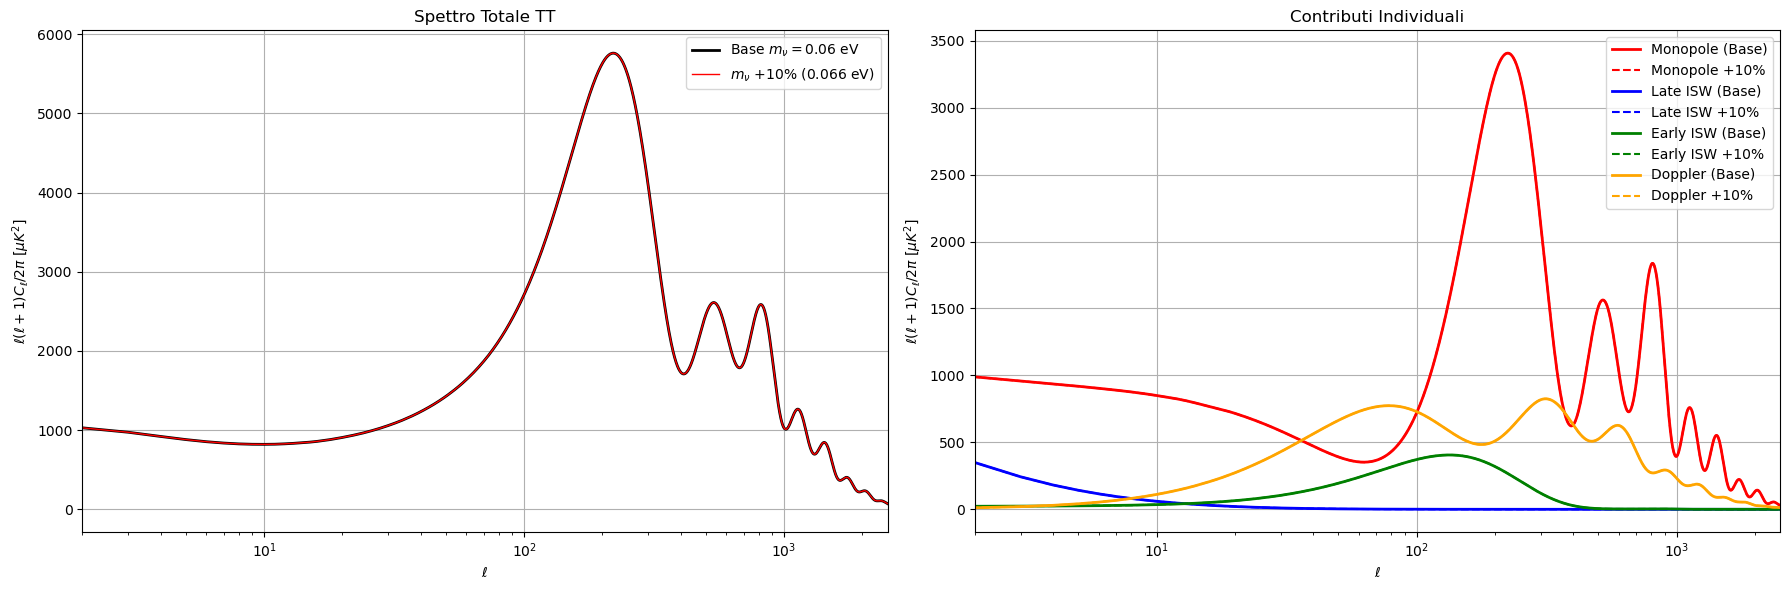

In [6]:
# Parametri base + massa neutrini Planck18
params_base = {
    'H0': 67.66,
    'ombh2': 0.02242,
    'omch2': 0.11934,
    'As': 2.1e-9,
    'ns': 0.9649,
    'tau': 0.0544,
    'mnu': 0.06 # somma masse neutrini in eV (Planck 2018 base)
}

# Funzione per calcolare spettro e contributi
def get_spectra(pars_dict):
    pars = camb.set_params(**pars_dict)
    monopole_source, ISW, doppler, quadrupole_source = get_scalar_temperature_sources()
    a = sympy.Symbol('a')
    early_ISW = sympy.Piecewise((ISW, 1 / a - 1 > 30), (0, True))
    late_ISW = ISW - early_ISW
    names = ['mon', 'ISW', 'eISW', 'LISW', 'dop', 'Q']
    pars.set_custom_scalar_sources(
        [monopole_source, ISW, early_ISW, late_ISW, doppler, quadrupole_source],
        source_names=names
    )
    data = camb.get_results(pars)
    dic = data.get_cmb_unlensed_scalar_array_dict(CMB_unit='muK')
    return dic

# Calcolo spettro base
dic_base = get_spectra(params_base)
ls = np.arange(dic_base['TxT'].shape[0])

# Variazione +10% su mnu 
params_up = params_base.copy()
params_up['mnu'] *= 1.1  # +10%
dic_up = get_spectra(params_up)

# Plotto
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax1 = axes[0]
ax1.semilogx(ls, dic_base['TxT'], color='k', lw=2, label='Base $m_\\nu = 0.06$ eV')
ax1.semilogx(ls, dic_up['TxT'], color='r', lw=1, label='$m_\\nu$ +10% (0.066 eV)')
ax1.set_xlabel(r'$\ell$')
ax1.set_ylabel(r'$\ell(\ell+1)C_\ell/2\pi\ [\mu K^2]$')
ax1.set_title('Spettro Totale TT')
ax1.set_xlim(2, ls[-1])
ax1.legend()
ax1.grid()

# Contributi separati 
ax2 = axes[1]
ax2.semilogx(ls, dic_base['monxmon'], color='red', lw=2, label='Monopole (Base)')
ax2.semilogx(ls, dic_up['monxmon'], ls='--', color='red', label='Monopole +10%')

ax2.semilogx(ls, dic_base['LISWxLISW'], color='blue', lw=2, label='Late ISW (Base)')
ax2.semilogx(ls, dic_up['LISWxLISW'], ls='--', color='blue', label='Late ISW +10%')

ax2.semilogx(ls, dic_base['eISWxeISW'], color='green', lw=2, label='Early ISW (Base)')
ax2.semilogx(ls, dic_up['eISWxeISW'], ls='--', color='green', label='Early ISW +10%')

ax2.semilogx(ls, dic_base['dopxdop'], color='orange', lw=2, label='Doppler (Base)')
ax2.semilogx(ls, dic_up['dopxdop'], ls='--', color='orange', label='Doppler +10%')

ax2.set_xlabel(r'$\ell$')
ax2.set_ylabel(r'$\ell(\ell+1)C_\ell/2\pi\ [\mu K^2]$')
ax2.set_title('Contributi Individuali')
ax2.set_xlim(2, ls[-1])
ax2.legend()
ax2.grid()
plt.tight_layout()
plt.show()


NB: The change is very subtle ! maybe the value of m that i have used is no good  

I expected: se T neutrini>>massa neutrini allora si comportano in modo relativistico, altrimenti come particelle massive -> all'inzio, con universo caldo, neutrini sono radiazione, poi diventano materia -> neutrini sono comunque radiazione per più tempo del resto dell'uni, che è già materia e contribuiscono al contenuto radiazione -> uguaglianza materia-radiazione ritardata a causa della presenza dei neutrini massivi -> potenziali decadono (in epoca rad.) più a lungo prima di diventare costanti (epoca matt.), quindi oscillazioni meno amplificate e dall'altra parte se epoca equivalenza è dopo ho più forte early ISW

We can try with another parameter, like the dark energy equation of state parameter (w)

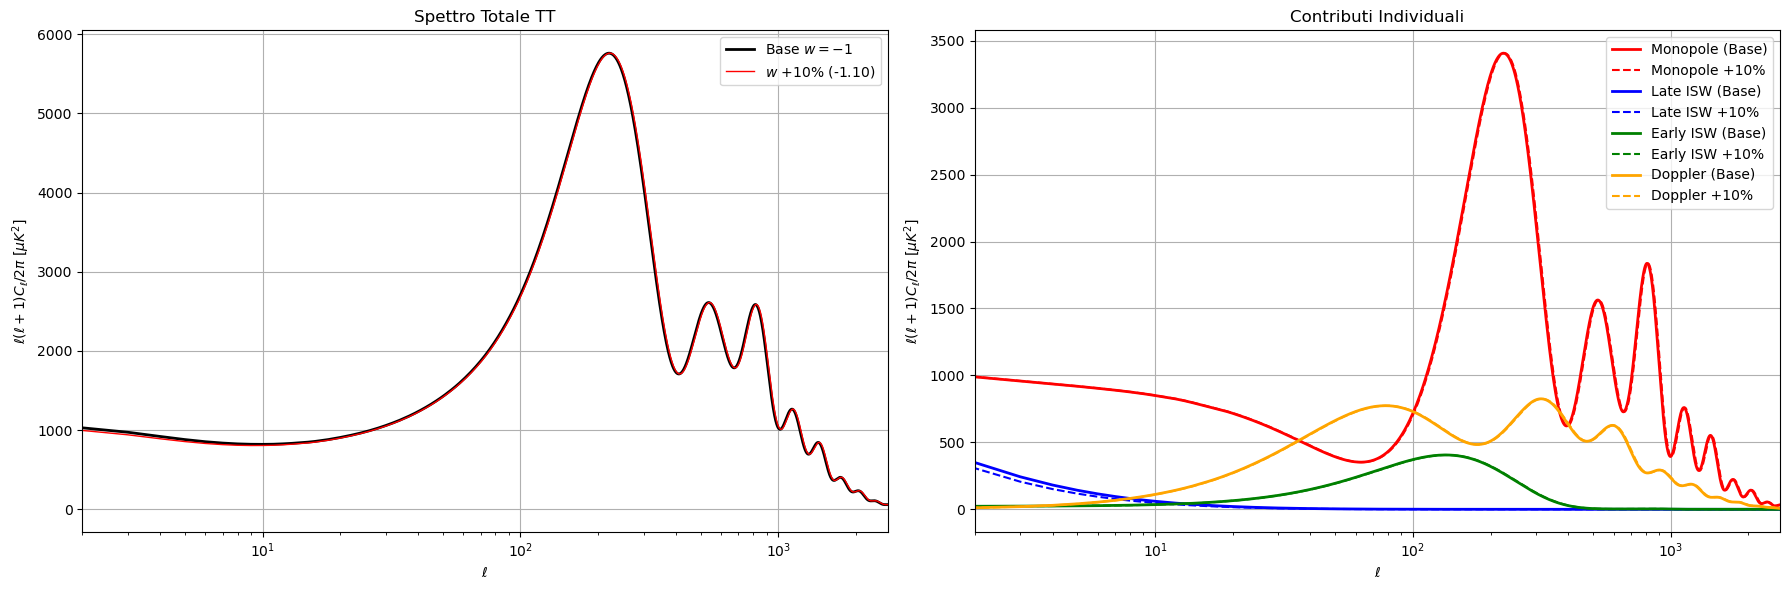

In [7]:
# Funzione per calcolare spettro e contributi
def get_spectra(H0, ombh2, omch2, As, ns, tau, w):
    pars = camb.CAMBparams()
    pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2, tau=tau, mnu=0.06)
    pars.set_dark_energy(w=w)
    pars.InitPower.set_params(As=As, ns=ns)
    pars.set_for_lmax(2500, lens_potential_accuracy=0)

    monopole_source, ISW, doppler, quadrupole_source = get_scalar_temperature_sources()
    a = sympy.Symbol('a')
    early_ISW = sympy.Piecewise((ISW, 1 / a - 1 > 30), (0, True))
    late_ISW = ISW - early_ISW

    names = ['mon', 'ISW', 'eISW', 'LISW', 'dop', 'Q']
    pars.set_custom_scalar_sources(
        [monopole_source, ISW, early_ISW, late_ISW, doppler, quadrupole_source],
        source_names=names
    )

    data = camb.get_results(pars)
    dic = data.get_cmb_unlensed_scalar_array_dict(CMB_unit='muK')
    return dic

# Parametri Planck18 + w base
H0 = 67.66
ombh2 = 0.02242
omch2 = 0.11934
As = 2.100e-9
ns = 0.9649
tau = 0.0544
w_base = -1  #lambdacdm

# Calcola spettro base
dic_base = get_spectra(H0, ombh2, omch2, As, ns, tau, w_base)
ls = np.arange(dic_base['TxT'].shape[0])

# Calcolo spettro con variazione +10% su w
w_up = w_base * 1.1  # -1 * 1.1 = -1.1
dic_up = get_spectra(H0, ombh2, omch2, As, ns, tau, w_up)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax1 = axes[0]
ax1.semilogx(ls, dic_base['TxT'], color='k', lw=2, label=f'Base $w = {w_base}$')
ax1.semilogx(ls, dic_up['TxT'], color='r', lw=1, label=f'$w$ +10% ({w_up:.2f})')
ax1.set_xlabel(r'$\ell$')
ax1.set_ylabel(r'$\ell(\ell+1)C_\ell/2\pi\ [\mu K^2]$')
ax1.set_title('Spettro Totale TT')
ax1.set_xlim(2, ls[-1])
ax1.legend()
ax1.grid()

ax2 = axes[1]
ax2.semilogx(ls, dic_base['monxmon'], color='red', lw=2, label='Monopole (Base)')
ax2.semilogx(ls, dic_up['monxmon'], ls='--', color='red', label='Monopole +10%')

ax2.semilogx(ls, dic_base['LISWxLISW'], color='blue', lw=2, label='Late ISW (Base)')
ax2.semilogx(ls, dic_up['LISWxLISW'], ls='--', color='blue', label='Late ISW +10%')

ax2.semilogx(ls, dic_base['eISWxeISW'], color='green', lw=2, label='Early ISW (Base)')
ax2.semilogx(ls, dic_up['eISWxeISW'], ls='--', color='green', label='Early ISW +10%')

ax2.semilogx(ls, dic_base['dopxdop'], color='orange', lw=2, label='Doppler (Base)')
ax2.semilogx(ls, dic_up['dopxdop'], ls='--', color='orange', label='Doppler +10%')

ax2.set_xlabel(r'$\ell$')
ax2.set_ylabel(r'$\ell(\ell+1)C_\ell/2\pi\ [\mu K^2]$')
ax2.set_title('Contributi Individuali')
ax2.set_xlim(2, ls[-1])
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.show()


MARKDOWN:  
w<-1 -> la densità dell’energia oscura era più bassa nel passato -> ci ha messo più tempo a diventare dominante -> potenziali decadono più tardi -> late ISW più debole -> anisotropie a piccoli l sono più basse

2) https://pla.esac.esa.int/#home , sotto cosmologia-CMB ang.p.s ho trovato il file che cercavo (COM_PowerSpect_CMB-TT-full_R3.01.txt)

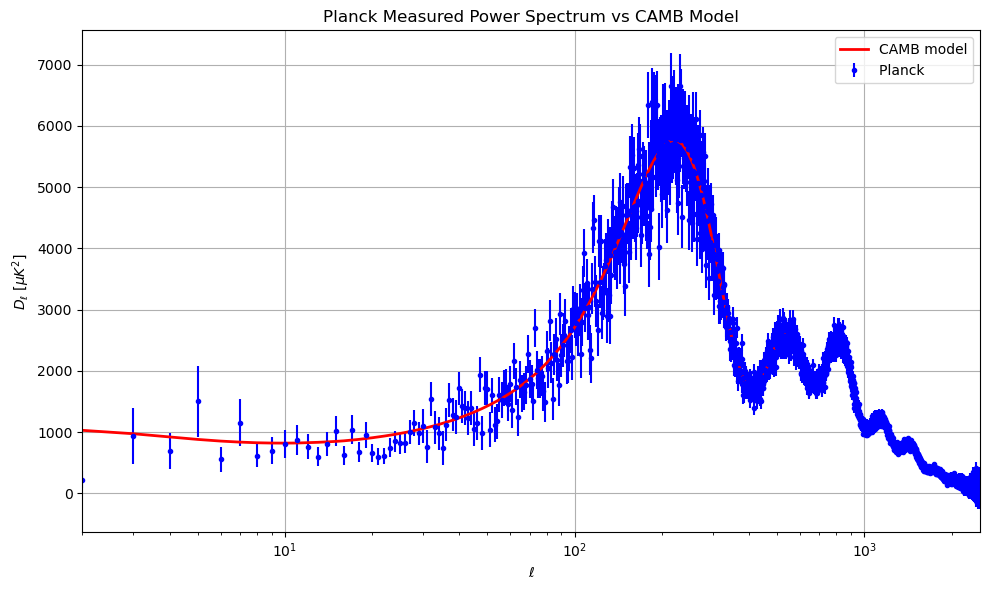

In [8]:
# carico dati presi dal telescopio Planck, che rileva il segnale della CMB 
filename = 'COM_PowerSpect_CMB-TT-full_R3.01.txt'
data = np.loadtxt(filename)

# Estraggo colonne dal file
# Colonne: 0 = ell=l, 1 = Dl, 2 = err
ell_planck = data[:, 0]  #multipoli
Dl_planck = data[:, 1]  #spettro 
err_planck = data[:, 2]  #errore sui dati

# Plot confronto dati Planck vs modello CAMB
plt.figure(figsize=(10, 6))
plt.errorbar(ell_planck, Dl_planck, yerr=err_planck, fmt='o', markersize=3, label='Planck ', color='blue')
plt.semilogx(ls, dic_base['TxT'], label='CAMB model', lw=2, color='red')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$D_\ell\ [\mu K^2]$')
plt.title('Planck Measured Power Spectrum vs CAMB Model')
plt.xlim(2, max(ell_planck))
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


NB: osservo che le barre di errore sono più grandi a l piccole, questo perchè: ho un numero finito di modi ad ogni l, sono 2l+1, quindi se l è un valore basso ho meno modi -> pochi campioni -> statistica debole -> errori più larghi